# Stochastic process simulations

We want to study how the state of a system evolves, given a probability of transition from each state.

What is a stochastic process?

A stochastic process is a collection of random variables $\{X_t, t \in I\}$ where 
X
t
  is the set of random variables at time  
t
  and  
I
  is the index set of the process.

Stochastic processes are widely used as mathematical models to study:

the growth of a bacterial population;
an electrical current fluctuating due to thermal noise;
the movement of a gas molecule;
stock prices evolution.

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import random as rn

## Simulation of gambler's ruin

We have a gambler who starts with 20 euros.

He can only win or lose 1 euro per bet.

He will keep gambling until he either loses all his money or he wins 40 euros.

He will keep on gambling until he either loses all his money or he wins 40 euros

Decido di modellare la probabilità in maniera equa: 50% di probabilità per entrambi gli outcome.

$
X_t =
\begin{cases}
+1 \text{ euro}, & \text{with a probability of } 50\% \\
-1 \text{ euro}, & \text{with a probability of } 50\%
\end{cases}
$

This is an example of a discrete stochastic process.

To implement the process, we can use the function random.choices, that handles weighted extractions.

In [75]:
rn.choices([-1, +1], weights=[0.5, 0.5])

[-1]

Questa funzione gestisce anche pesi che non sommano a 1, in quel caso vengono normalizzati.

Questa funzione ritorna una lista, quindi posso usare:

In [76]:
rn.choices([-1, +1], weights=[0.5, 0.5])[0]

-1

Scrivo una funzione per l'evoluzione del sistema:

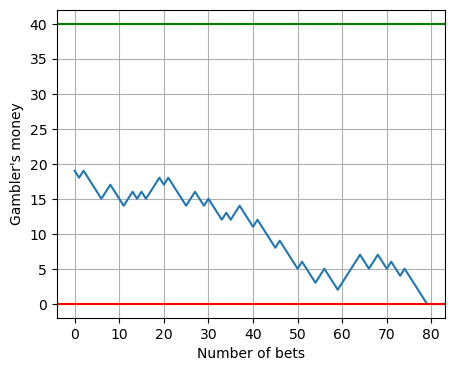

In [77]:
def gr(g_start, # soldi iniziali
       g_goal   # soldi da raggiungere
       ):
    g_money = g_start
    g_simulations = [] # lista per tenere traccia dell'andamento del denaro durante la simulazione
    while g_money in range(1, g_goal):
        event= rn.choices([-1, +1], weights=[0.5, 0.5])[0]
        g_money += event
        g_simulations.append(g_money)
    return g_simulations

g_simulation = gr(20, 40)

plt.figure(figsize=(5,4))
plt.plot(g_simulation)
plt.axhline(y=0, color='r')
plt.axhline(y=40, color='g')
plt.xlabel('Number of bets')
plt.ylabel('Gambler\'s money')
plt.grid(True)
plt.show()

## Mathematical Result for a fair game

Let:

* $p = q = 0.5$ (fair coin)
* $x$ = starting money
* $N$ = target money

Then the probability of ruin (reaching 0 before N) is:

$
P_{ruin} = 1 - \frac{x}{N}
$

So even if the game is fair:

* if you start with 10 euros and your target is 100 euros $\rightarrow P_{ruin} = 0.9$
* You're very likely to go broke before reaching the goal

Come controllo che la simulazione stia rispettando il risultato matematico?

In [78]:
def ruin_prob(g_start, g_goal):
    rp = (g_goal - g_start)/g_goal
    return rp

ruin_prob(20, 40)

0.5

Ripeto il processo stocastico più volte:

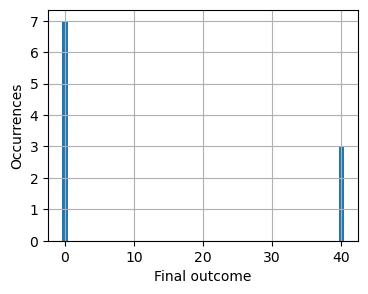

In [79]:
final_outcomes = []

while len(final_outcomes) < 10:
    sim = gr(20, 40)
    final_outcomes.append(sim[-1])

from collections import Counter

distribution = Counter(final_outcomes)

plt.figure(figsize=(4,3))
plt.bar(distribution.keys(), distribution.values())
plt.xlabel('Final outcome')
plt.ylabel('Occurrences')
plt.grid(True)
plt.show()


Non sono equamente distribuite, provo quindi ad aumentare il numero di simulazioni:

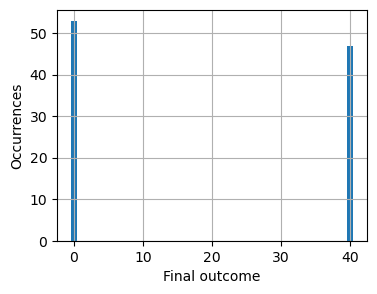

In [80]:
final_outcomes = []

while len(final_outcomes) < 100:
    sim = gr(20, 40)
    final_outcomes.append(sim[-1])

distribution = Counter(final_outcomes)

plt.figure(figsize=(4,3))
plt.bar(distribution.keys(), distribution.values())
plt.xlabel('Final outcome')
plt.ylabel('Occurrences')
plt.grid(True)
plt.show()

Quindi, per vedere il processo stocastico convergere alla teoria bisogna runnarlo molte volte, altrimenti non riesco a vedere se la simulazione si sta comportando bene.

## Evolution of the number of molecules in an environment

I have a system where I want to keep track of the number of molecules in an environment.

The number of molecules can change due to two different processes:

* a particle from the outside can come in with a probability that is constant (or can be approximated as such);
* a particle can escape the system, with a probability that is constant for each particle (so the total probability is proportional to the number of particles).

In questo caso voglio monitorare il tempo tra uno step e il successivo.

In [81]:
def removal(state):  # questa funzione rappresenta il tasso di rimozione della particella, dipende dal numero corrente di particelle (state)
    return state*0.1

def increase(state):
    return 1

transitions = [removal, increase]
transitions_names = ['removal', 'increase']

# la provbabilità di ogni transizione dipende dal numero di particelle
# è un sistema markoviano, quindi la probabilità di ogni transizione dipende solo dallo stato attuale (state) e non da come ci siamo arrivati a quello stato

# inizio con un sistema con 5 particelle
state = 5

rates = [f(state) for f in transitions]
print(rates)

[0.5, 1]


## The transition rate

The total rate $\lambda_{tot}$ is the sum of the rates.

The chance of each one happening is the proportion compared to the total rate.

The time for which the system keeps being in the same state is distributed with an exponential time $\tau = \lambda^{-1}_{tot}$

Calcolo il total rate:

In [82]:
total_rate = sum(rates)
print(total_rate)

time = np.random.exponential(1/total_rate)
print(time)

1.5
3.214711122461225


Choosing the transition

We can use again the function random.choices, that handles weighted extractions:

In [83]:
rn.choices(transitions_names, weights=rates)

event = rn.choices(transitions_names, weights=rates)[0]
print(event)

removal


## Updating the status

Given the chosen event, we can update the current status and then start all over.

In [84]:
if event == 'increase':
    state += 1
elif event == 'removal':
    state -= 1
else:
    raise ValueError("transition not recognized")

## The complete cycle

The complete simulation requires to keep track of which transition happened, how much time the system has spent in each status and so on.

Another thing we might want to keep track of is the total time elapsed in the simulation.

When should we stop our simulation?

Ideally we should stop after a certain amount of "simulated time" has passed.

In [85]:
import typing
from enum import Enum

The `typing` library in Python is used to provide **type hints** — annotations that indicate the expected data types of variables, function arguments, and return values. This helps with:

* **Code clarity** – Makes it easier to understand what types a function or variable expects.
* **Static analysis** – Tools like mypy and pyright can detect bugs before runtime.
* **Autocompletion** and **documentation** – Improves developer productivity in editors.

The `Enum` function from Python’s built-in `enum` module is used to create enumerations, which are sets of symbolic names bound to unique, constant values. `Enum` makes code more readable, prevent invalid values, and can be compared easily.

Let's see how we can use them to implement our code.

In [86]:
class Transition(Enum):
    INCREASE = 'increase'
    DECREASE = 'removal'

class Observation(typing.NamedTuple): # una classe che tiene traccia ad ogni step del processo con:
    state: typing.Any                 # lo stato del sistema (es. numero di particelle)
    time_of_observation: float        # il tempo in cui è stata fatta l'osservazione
    time_of_residency: float          # il tempo trascorso in quello stato prima di fare l'osservazione
    transition: Transition            # la transizione che ha portato alla nuova osservazione

Observation(5, 1.0, 0.33, Transition.DECREASE)


Observation(state=5, time_of_observation=1.0, time_of_residency=0.33, transition=<Transition.DECREASE: 'removal'>)

Quindi ogni step dell'evoluzione è dato da un elemento di questa classe.

Ora riscrivo tutto in termini di classi:

In [87]:
transitions = [removal, increase]
transitions_names = [Transition.DECREASE, Transition.INCREASE]

observed_states = []
state = 5
total_time = 0.0
time_limit = 5.0

while total_time < time_limit:
    rates = [f(state) for f in transitions]
    total_rate = sum(rates)
    time = np.random.exponential(1/total_rate)
    event = rn.choices(transitions_names, weights=rates)[0]
    
    observation = Observation(state, total_time, time, event)
    print(observation)
    observed_states.append(observation)
    
    total_time += time
    
    if event == Transition.INCREASE:
        state += 1
    elif event == Transition.DECREASE:
        state -= 1
    else:
        raise ValueError("transition not recognized")

Observation(state=5, time_of_observation=0.0, time_of_residency=0.3588176838711884, transition=<Transition.INCREASE: 'increase'>)
Observation(state=6, time_of_observation=0.3588176838711884, time_of_residency=0.6203081171516396, transition=<Transition.INCREASE: 'increase'>)
Observation(state=7, time_of_observation=0.979125801022828, time_of_residency=0.033346319613132946, transition=<Transition.INCREASE: 'increase'>)
Observation(state=8, time_of_observation=1.012472120635961, time_of_residency=1.15242331391755, transition=<Transition.INCREASE: 'increase'>)
Observation(state=9, time_of_observation=2.164895434553511, time_of_residency=1.5393150071861086, transition=<Transition.DECREASE: 'removal'>)
Observation(state=8, time_of_observation=3.7042104417396198, time_of_residency=1.5539330656025205, transition=<Transition.INCREASE: 'increase'>)


In questo modo vedo tutti i dati ad ogni step (numero di prticelle, tempo di osservazione, ecc.)

Let's make it a function so we have a more general way of managing it.

In [88]:
def simulation(starting_state, time_limit):
    observed_states = []
    state = starting_state
    total_time = 0.0

    while total_time < time_limit:
        rates = [f(state) for f in transitions]
        total_rate = sum(rates)
        time = np.random.exponential(1/total_rate)
        event = rn.choices(transitions_names, weights=rates)[0]

        observation = Observation(state, total_time, time, event)
        observed_states.append(observation)

        total_time += time

        if event == Transition.INCREASE:
            state += 1
        elif event == Transition.DECREASE:
            state -= 1
        else:
            raise ValueError("transition not recognized")
    return observed_states

time_limit = 100
result = simulation(starting_state=5, time_limit=time_limit)
print(f"Total observations: {len(result)}")

for res in result[-5:]:
    print(res)

Total observations: 225
Observation(state=7, time_of_observation=94.5782065979212, time_of_residency=0.7139172517358037, transition=<Transition.DECREASE: 'removal'>)
Observation(state=6, time_of_observation=95.292123849657, time_of_residency=0.3590724380841551, transition=<Transition.INCREASE: 'increase'>)
Observation(state=7, time_of_observation=95.65119628774116, time_of_residency=0.6043729921833696, transition=<Transition.INCREASE: 'increase'>)
Observation(state=8, time_of_observation=96.25556927992453, time_of_residency=0.46830945195583973, transition=<Transition.INCREASE: 'increase'>)
Observation(state=9, time_of_observation=96.72387873188038, time_of_residency=3.748885758084121, transition=<Transition.INCREASE: 'increase'>)


## Final probability distribution

Abbiamo fatto evolvere il sistema fino ad certo tempo limite. Voglio stimare la probabilità di osservare il sistema in un dato stato: sommo il tempo che il sistema ha passato in ogni stato.

To estimate the probability of observing our system in a given state, we have to sum up the time the system has spent in each state.

**BEWARE**: the probability depends on the time of residency, not on the number of times that state has appeared!

The expected distribution for this process is a Poisson distribution with average 10.

* Perché è una Poissonaina?
Stiamo lavorando con variabili discrete. Questi eventi sono indipendenti l'uno dall'altro.
* Perché la media è 10?
All'equilibrio raggiungiamo un numero stabile di molecole; nel nostro caso abbiamo un tasso di 1 per l'ingresso e 0.$1*n$ per l'uscita. Quindi ho equilibrio quando $n = 10$.

Mi calcolo la distribuzione della funzione:

Counter({6: 0.10231908296040375, 9: 0.10090641996597637, 5: 0.07837310841838695, 7: 0.07811502073060382, 13: 0.07210316122045388, 8: 0.06497912961145486, 12: 0.0592509999856242, 11: 0.05834265137276328, 15: 0.05778384308002647, 16: 0.056664075890128215, 4: 0.05476199554152476, 10: 0.05450713702278541, 14: 0.05070330752069176, 17: 0.026836255356521045, 18: 0.0249307652987473, 19: 0.020395835595583743, 3: 0.01899918610639671, 2: 0.018391430275442648, 20: 0.004056272902921203, 21: 0.002307966043208223})


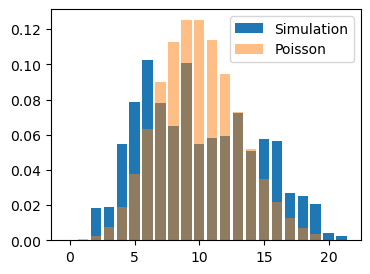

In [89]:
from collections import Counter

distribution = Counter()
for observation in result:
    state = observation.state
    residency_time = observation.time_of_residency
    distribution[state] += residency_time/time_limit
print(distribution)

import scipy.stats as st
plt.figure(figsize=(4,3)) 

plt.bar(distribution.keys(), distribution.values(), label='Simulation')

values = np.arange(20)
pmf = st.poisson(10).pmf(values)

plt.bar(values, pmf, alpha=0.5, label='Poisson')
plt.legend(loc='best')
plt.show()

La simulazione non converge.

Let's make it run for longer.

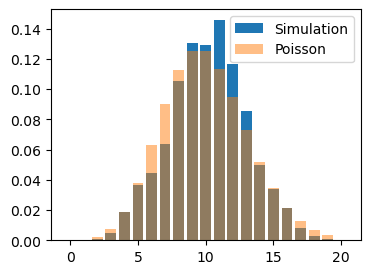

In [90]:
def generate_distribution(observation_sequence):
    distribution = Counter()
    for observation in observation_sequence:
        state = observation.state
        residency_time = observation.time_of_residency
        distribution[state] += residency_time
        
    total_time_observed = sum(distribution.values())
    for state in distribution:
        distribution[state] /= total_time_observed
    return distribution

time_limit = 1000
result = simulation(starting_state=5, time_limit=time_limit)
distribution = generate_distribution(result)

plt.figure(figsize=(4,3)) 

plt.bar(distribution.keys(), distribution.values(), label='Simulation')

values = np.arange(20)
pmf = st.poisson(10).pmf(values)

plt.bar(values, pmf, alpha=0.5, label='Poisson')
plt.legend(loc='best')
plt.show()


Potrei fare un'analisi statistica per vedere se le due distribuzioni sono compatibili.

## Warm-in period

In generale, il punto iniziale della simulazione ha un ruolo.

For monodimensional systems it's relatively easy to converge to the right distribution, but the starting point can have a substancial effect.

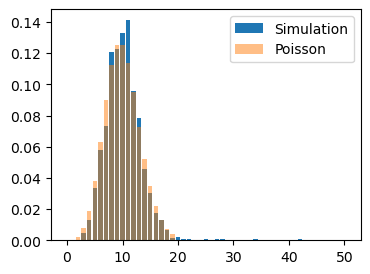

In [91]:
time_limit = 1000
result = simulation(starting_state=50,      # inizio con 50 particelle
                    time_limit=time_limit)
distribution = generate_distribution(result)

plt.figure(figsize=(4,3)) 

plt.bar(distribution.keys(), distribution.values(), label='Simulation')

values = np.arange(20)
pmf = st.poisson(10).pmf(values)

plt.bar(values, pmf, alpha=0.5, label='Poisson')
plt.legend(loc='best')
plt.show()

Dato che in questo caso ho una cosa sulla destra molto marcata, è possibile che un test statistico dica che la distribuzione ottenuta non è una Poisson. Quindi ho introdotto un bias.

## Multiple simulations

Estimating the convergence to the final distribution can be quite hard with a single simulation, so a good rule of thumb is to run at least 3 or 4 identical simulations to assess how much the convergence has been reached

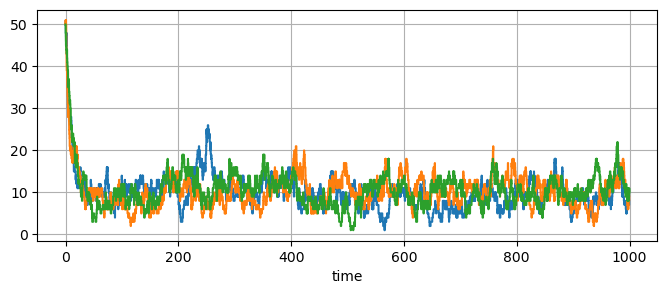

In [94]:
time_limit = 1_000
result_1 = simulation(starting_state=50, time_limit=time_limit)
result_2 = simulation(starting_state=50, time_limit=time_limit)
result_3 = simulation(starting_state=50, time_limit=time_limit)

def plot_observations(observation_sequence, ax=None):
    if ax is None:
        ax = plt.gca()
    values = [obs.state for obs in observation_sequence]
    times = [obs.time_of_observation for obs in observation_sequence]
    ax.step(times, values, where='post')

fig = plt.figure(figsize=(8,3))
plot_observations(result_1)
plot_observations(result_2)
plot_observations(result_3)
plt.xlabel('time')
plt.grid(True)
plt.show()

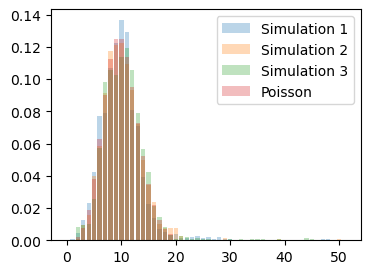

In [95]:
distribution_1 = generate_distribution(result_1)
distribution_2 = generate_distribution(result_2)
distribution_3 = generate_distribution(result_3)

fig = plt.figure(figsize=(4,3))
plt.bar(distribution_1.keys(), distribution_1.values(), alpha=0.3, label='Simulation 1')
plt.bar(distribution_2.keys(), distribution_2.values(), alpha=0.3, label='Simulation 2')
plt.bar(distribution_3.keys(), distribution_3.values(), alpha=0.3, label='Simulation 3')

values = np.arange(20)
pmf = st.poisson(10).pmf(values)

plt.bar(values, pmf, alpha=0.3, label='Poisson')
plt.legend(loc='best')
plt.show()


## Absorbing states

Voglio simulare anche il fatto che, se arrivo in uno stato in cui non ci sono più molecole, allora il sistema resta in quello stato.

An absorbing state is one where the transition rates for all the possible transitions are equal to zero.

When this happens, the expected residency time becomes infinite (the system is stuck there).

Let's rewrite our functions so that 0 is an absorbing state.

In [ ]:
class Transition(Enum):
    INCREASE = 'increase'
    DECREASE = 'removal'
    ABSORPION = 'absorbed'

def removal_absorbing(state):
    return state*0.5

def increase_absorbing(state):
    return 1 if state>0 else 0 # come prima, ma state = 0 allora non posso più aumentare, quindi tasso di aumento è 0

transitions = [removal_absorbing, increase_absorbing]
transitions_names = [Transition.DECREASE, Transition.INCREASE]

state = 1
rates = [f(state) for f in transitions]
print(f"Rates at state {state}: {rates}")
total_rate = sum(rates)
print(f"Total rate at state {state}: {total_rate}")

state = 0
rates = [f(state) for f in transitions]
print(f"Rates at state {state}: {rates}")
total_rate = sum(rates)
print(f"Total rate at state {state}: {total_rate}")

if total_rate>0:
    time = np.random.exponential(1/total_rate)
else:
    time = np.inf
print(time)

Rates at state 1: [0.5, 1]
Total rate at state 1: 1.5
Rates at state 0: [0.0, 0]
Total rate at state 0: 0.0


At this point we should not be advancing anymore.

In [102]:
def simulation(starting_state, time_limit, transitions, transitions_names):
    observed_states = []
    state = starting_state
    total_time = 0.0

    while total_time < time_limit:
        rates = [f(state) for f in transitions]
        total_rate = sum(rates)
        if total_rate>0:
            time = np.random.exponential(1/total_rate)
            event = rn.choices(transitions_names, weights=rates)[0]
        else:
            time = np.inf
            event = Transition.ABSORPION
            
        observation = Observation(state, total_time, time, event)
        observed_states.append(observation)

        total_time += time

        if event == Transition.INCREASE:
            state += 1
        elif event == Transition.DECREASE:
            state -= 1
        elif event == Transition.ABSORPION:
            pass
        else:
            raise ValueError("transition not recognized")
    return observed_states

result = simulation(5, time_limit=100,
                    transitions=[removal_absorbing, increase_absorbing],
                    transitions_names=[Transition.DECREASE, Transition.INCREASE])

for observation in result:
    print(observation)

Observation(state=5, time_of_observation=0.0, time_of_residency=0.24332337717964053, transition=<Transition.DECREASE: 'removal'>)
Observation(state=4, time_of_observation=0.24332337717964053, time_of_residency=0.016295458141679348, transition=<Transition.INCREASE: 'increase'>)
Observation(state=5, time_of_observation=0.2596188353213199, time_of_residency=0.4047322069237925, transition=<Transition.DECREASE: 'removal'>)
Observation(state=4, time_of_observation=0.6643510422451124, time_of_residency=0.07517734142871568, transition=<Transition.INCREASE: 'increase'>)
Observation(state=5, time_of_observation=0.7395283836738281, time_of_residency=0.1976390132570739, transition=<Transition.DECREASE: 'removal'>)
Observation(state=4, time_of_observation=0.937167396930902, time_of_residency=0.19282559109714031, transition=<Transition.INCREASE: 'increase'>)
Observation(state=5, time_of_observation=1.1299929880280424, time_of_residency=0.04965755444067995, transition=<Transition.DECREASE: 'removal'>

## Fixed time events

One possibility we might be interested in could be to register events happening at fixed point in time (or space, if we are describing the movement of an object).

The advantage of working with markovian transitions is that there is no problem interrupting at a fixed point in time and then keep going from there as nothing happened.

In [118]:
class Transition(Enum):
    INCREASE = 'increase'
    DECREASE = 'removal'
    ABSORPION = 'absorbed'
    RINGTONE = 'ringtone'

def removal_absorbing(state):
    return state*0.5

def increase_absorbing(state):
    return 1 if state>0 else 0

transitions = [removal_absorbing, increase_absorbing]
transitions_names = [Transition.DECREASE, Transition.INCREASE]

state = 5
rates = [f(state) for f in transitions]
print(f"Rates at state {state}: {rates}")

total_rate = sum(rates)
print(f"Total rate at state {state}: {total_rate}")

proposed_residency_time = np.random.exponential(1/total_rate)
print(f"Proposed residency time: {proposed_residency_time}")

current_time = 0.1
time_ringtone = 0.3

if current_time<time_ringtone and current_time + proposed_residency_time > time_ringtone:
    proposed_residency_time = time_ringtone - current_time
    event = Transition.RINGTONE
else:
    pass

print(event)

Rates at state 5: [2.5, 1]
Total rate at state 5: 3.5
Proposed residency time: 0.22845998137041112
Transition.RINGTONE


Now we have to decide how to interact with the absorbing states.

A good practice is to prioritize timed events.

In [119]:
def simulation(starting_state, time_limit, transitions, transitions_names):
    observed_states = []
    state = starting_state
    total_time = 0.0

    while total_time < time_limit:
        rates = [f(state) for f in transitions]
        total_rate = sum(rates)
        if total_rate>0:
            time = np.random.exponential(1/total_rate)
            event = rn.choices(transitions_names, weights=rates)[0]
        else:
            time = np.inf
            event = Transition.ABSORPION
        
        # the fixed events overrides the others if they would happen before the chosen time
        time_ringtone = 1.0
        if total_time < time_ringtone and total_time + time > time_ringtone:
            time = time_ringtone - total_time
            event = Transition.RINGTONE
            
        observation = Observation(state, total_time, time, event)
        observed_states.append(observation)

        total_time += time

        if event == Transition.INCREASE:
            state += 1
        elif event == Transition.DECREASE:
            state -= 1
        elif event == Transition.ABSORPION or event == Transition.RINGTONE:
            pass
        else:
            raise ValueError("transition not recognized")
    return observed_states

result = simulation(5, time_limit=100,
                    transitions=[removal_absorbing, increase_absorbing],
                    transitions_names=[Transition.DECREASE, Transition.INCREASE])

for observation in result[:6]:
    print(observation)

Observation(state=5, time_of_observation=0.0, time_of_residency=0.1671142695938883, transition=<Transition.DECREASE: 'removal'>)
Observation(state=4, time_of_observation=0.1671142695938883, time_of_residency=0.295420091075254, transition=<Transition.INCREASE: 'increase'>)
Observation(state=5, time_of_observation=0.46253436066914233, time_of_residency=0.5374656393308577, transition=<Transition.RINGTONE: 'ringtone'>)
Observation(state=5, time_of_observation=1.0, time_of_residency=0.2384923447236527, transition=<Transition.DECREASE: 'removal'>)
Observation(state=4, time_of_observation=1.2384923447236527, time_of_residency=0.4375777754927433, transition=<Transition.DECREASE: 'removal'>)
Observation(state=3, time_of_observation=1.676070120216396, time_of_residency=0.24564741360579237, transition=<Transition.INCREASE: 'increase'>)


## Continuous time Markov Chain

This is an exact simulation algorithm for continuous-time Markov chains and represents the basics for the generalization to the continuous time random walk simulation.

The idea of rate-driven random events in continuous time is at the core of many particle-transport simulations and is widely used to generate realistic synthetic data for imaging and deep learning, even if the implementation is usually more specialized.

## Exercise

There are still many things that can be done to implement this simulator:

1. return the simulation not as a list, but as a dedicated object that can:
* be sliced over time: `my_simulation[0.5:100.0]`;
* have a plot function dedicated
* automatically estimate the distribution
2. always include multiple runs of the simulation, and join this with point 1
3. allow the user to specify the effect of the various transitions